In [1]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Customer Data:
    CustomerID  AnnualIncome  SpendingScore
0            1            15             39
1            2            16             81
2            3            17              6
3            4            18             77
4            5            19             40
5            6            20             76
6            7            21              6
7            8            22             94
8            9            23              3
9           10            24             72
10          11            60             55
11          12            62             50
12          13            63             52
13          14            65             59
14          15            68             61
15          16            70             54
16          17            72             60
17          18            75             65
18          19            78             58
19          20            80             63


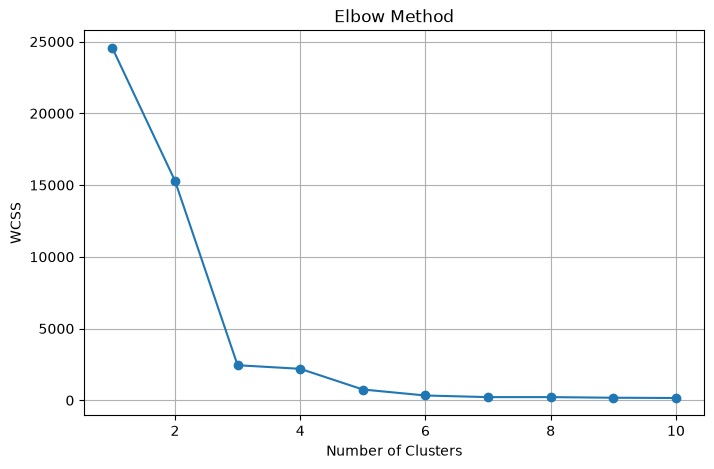


Clustered Data:
    CustomerID  AnnualIncome  SpendingScore  Cluster
0            1            15             39        2
1            2            16             81        3
2            3            17              6        2
3            4            18             77        3
4            5            19             40        2
5            6            20             76        3
6            7            21              6        2
7            8            22             94        0
8            9            23              3        2
9           10            24             72        3
10          11            60             55        1
11          12            62             50        1
12          13            63             52        1
13          14            65             59        1
14          15            68             61        1
15          16            70             54        1
16          17            72             60        1
17          18            75 

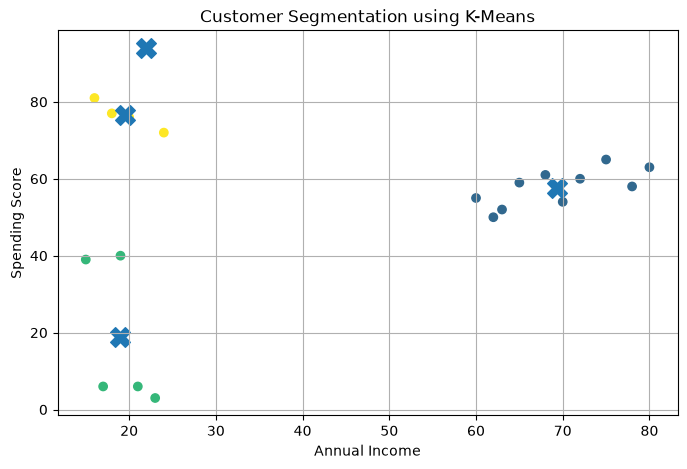

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("customers.csv")

print("Customer Data:")
print(df)

# Select features
X = df[["AnnualIncome", "SpendingScore"]]

# -----------------------------
# Elbow Method
# -----------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# -----------------------------
# K-Means Clustering
# -----------------------------
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X)

print("\nClustered Data:")
print(df)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"]
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)

plt.show()